<a href="https://colab.research.google.com/github/Ialdanah1/agentic-ai-engineering-labs/blob/main/02-faiss-ragas-rag-evaluation/faiss_rag_ragas_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://weclouddata.s3.amazonaws.com/images/logos/wcd_logo_new_2.png"  width='15%'>

<h1>Demo: LLM Indexing — FAISS + RAGAS Evaluation</h1>
Developed by WeCloudData &nbsp;·&nbsp; <i>upgraded edition</i>
<br></br>

**What changed from the original notebook**

| | Before | Now |
|---|---|---|
| Corpus | one 1928 short story, split into single **sentences** | **40,181 PubMed passages** (BioASQ), already paragraph-sized |
| Scale | ~1.5k vectors — too small for IVF/PQ to mean anything | ~40k vectors — the speed/accuracy trade-off becomes real |
| Ground truth | none | 707 questions with **reference answers** *and* **gold passage IDs** |
| Similarity | raw L2 on unnormalised vectors | L2 on **unit-normalised** vectors (= cosine ranking) |
| Generator | `flan-t5-base` (too weak to evaluate) | `gpt-4o-mini` |
| Evaluation | eyeballing the retrieved sentences | **RAGAS** metrics + recall@k, compared across all three index types |

The pedagogical payoff: the original notebook taught three index types but never showed
which one is *better*. Section 6 answers that with numbers.

## 0. Setup

In [ ]:
!nvidia-smi  # confirm the notebook has GPU access

Sun Aug 30 04:51:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# FAISS. The GPU build needs a session restart; faiss-cpu also works fine at this scale.
!pip install -q faiss-gpu-cu12

print("\nInstallation complete.")
print("!!! IMPORTANT: restart the session now — Runtime > Restart session — then continue. !!!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 17.5 MB/s eta 0:00:00

Installation complete.
!!! IMPORTANT: restart the session now — Runtime > Restart session — then continue. !!!


In [ ]:
!pip install -q sentence-transformers datasets
!pip install -q "ragas==0.4.3" openai nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.2/353.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests=

In [ ]:
import getpass, os

# RAGAS uses this model as an independent "judge", and we also use it to generate answers.
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

OpenAI API key: ··········


In [ ]:
# ---- knobs you may want to turn -------------------------------------------------
EMBED_MODEL   = "BAAI/bge-small-en-v1.5"   # retrieval encoder (384-dim, fast, strong)
GEN_MODEL     = "gpt-4o-mini"              # writes the answers
JUDGE_MODEL   = "gpt-4o-mini"              # scores the answers (RAGAS)
JUDGE_EMBED   = "text-embedding-3-small"   # used by answer-relevancy / semantic similarity

N_PASSAGES    = None   # None = index the whole 40k corpus; set e.g. 10000 to go faster
N_EVAL        = 20     # questions used in the RAGAS comparison — see the cost note in §6
TOP_K         = 10      # passages retrieved per question
# ---------------------------------------------------------------------------------

## 1. The corpus: biomedical passages with ground truth

[`enelpol/rag-mini-bioasq`](https://huggingface.co/datasets/enelpol/rag-mini-bioasq) is a
cleaned subset of the **BioASQ** biomedical QA challenge. It ships two configs:

* `text-corpus` — 40,181 PubMed-derived passages, each with an integer `id`
* `question-answer-passages` — questions, reference `answer`s, and `relevant_passage_ids`

That third column is what makes this corpus worth switching to. Because we know *which*
passages should have been retrieved, we can measure the retriever directly (recall@k),
independently of whatever the LLM decides to write. Sentence-split fiction gave us neither
the scale nor the labels to do this.

In [ ]:
from datasets import load_dataset

DATASET = "enelpol/rag-mini-bioasq"

corpus_ds = load_dataset(DATASET, "text-corpus")
qa_ds     = load_dataset(DATASET, "question-answer-passages")

print("corpus splits:", {k: len(v) for k, v in corpus_ds.items()})
print("qa splits    :", {k: len(v) for k, v in qa_ds.items()})
print("corpus cols  :", corpus_ds[list(corpus_ds)[0]].column_names)
print("qa cols      :", qa_ds[list(qa_ds)[0]].column_names)

README.md:   0%|          | 0.00/1.76k [00:00<?, ?B/s]

text-corpus/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 35.3MB            

text-corpus/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/40181 [00:00<?, ? examples/s]

question-answer-passages/train-00000-of-(…): reconstructing file:   0%|          |  0.00B / 1.12MB            

...

question-answer-passages/test-00000-of-0(…): reconstructing file:   0%|          |  0.00B /  187kB            

question-answer-passages/test-00000-of-0(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4012 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/707 [00:00<?, ? examples/s]

corpus splits: {'test': 40181}
qa splits    : {'train': 4012, 'test': 707}
corpus cols  : ['passage', 'id']
qa cols      : ['question', 'answer', 'id', 'relevant_passage_ids']


In [ ]:
# Take whichever split each config happens to expose, then drop empty/NaN passages.
corpus_split = corpus_ds["test"] if "test" in corpus_ds else corpus_ds[list(corpus_ds)[0]]

records = [
    (int(r["id"]), r["passage"].strip())
    for r in corpus_split
    if isinstance(r.get("passage"), str)
    and r["passage"].strip()
    and r["passage"].strip().lower() != "nan"
]

if N_PASSAGES:
    records = records[:N_PASSAGES]

passage_ids  = [pid for pid, _ in records]
passages     = [txt for _, txt in records]
id_to_row    = {pid: i for i, pid in enumerate(passage_ids)}   # gold id -> FAISS row

print(f"{len(passages):,} usable passages")
print(f"median length: {sorted(len(p.split()) for p in passages)[len(passages)//2]} words")
print("\n--- sample ---\n", passages[0][:400])

40,181 usable passages
median length: 204 words

--- sample ---
 New data on viruses isolated from patients with subacute thyroiditis de Quervain 
are reported. Characteristic morphological, cytological, some physico-chemical 
and biological features of the isolated viruses are described. A possible role 
of these viruses in human and animal health disorders is discussed. The isolated 
viruses remain unclassified so far.


In [ ]:
# Keep only questions whose gold passages actually survived the filtering above.
import ast

qa_split = qa_ds["test"] if "test" in qa_ds else qa_ds[list(qa_ds)[0]]

def parse_ids(v):
    if isinstance(v, str):
        v = ast.literal_eval(v)
    return [int(x) for x in v]

qa_pairs = []
for r in qa_split:
    gold = [i for i in parse_ids(r["relevant_passage_ids"]) if i in id_to_row]
    if gold and isinstance(r.get("answer"), str) and r["answer"].strip():
        qa_pairs.append({
            "question": r["question"].strip(),
            "answer":   r["answer"].strip(),
            "gold_ids": gold,
        })

print(f"{len(qa_pairs):,} questions with at least one gold passage in the index")
qa_pairs[0]

707 questions with at least one gold passage in the index


{'question': 'Is capmatinib effective for glioblastoma?',
 'answer': 'No. Combination of capmatinib buparlisib resulted in no clear activity in patients with recurrent PTEN-deficient glioblastoma.',
 'gold_ids': [31776899]}

## 2. Building document vectors

Two changes from the original beyond the corpus itself.

**A stronger encoder.** `BAAI/bge-small-en-v1.5` outperforms `all-mpnet-base-v2` on retrieval
benchmarks while being roughly three times faster — it matters when you are encoding 40k
passages instead of 1.5k sentences. BGE models expect an instruction prefix on the *query*
side only, which `encode_query` below handles.

**Unit normalisation.** With `normalize_embeddings=True` every vector has length 1, and for
unit vectors `‖a−b‖² = 2 − 2·(a·b)`. So ranking by L2 distance gives *exactly* the same order
as ranking by cosine similarity. This lets us keep `METRIC_L2` across all three index types —
including IVFPQ, whose inner-product support is patchier — while still doing cosine retrieval.

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np, torch

model = SentenceTransformer(EMBED_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

# BGE wants this prefix on queries; harmless to define even if you swap the model out.
QUERY_PREFIX = "Represent this sentence for searching relevant passages: " if "bge" in EMBED_MODEL.lower() else ""

def encode_query(texts):
    if isinstance(texts, str):
        texts = [texts]
    return np.asarray(
        model.encode([QUERY_PREFIX + t for t in texts], normalize_embeddings=True),
        dtype="float32",
    )

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
%%time
passage_embeddings = model.encode(
    passages,
    batch_size=128,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype("float32")

d = passage_embeddings.shape[1]
passage_embeddings.shape

Batches:   0%|          | 0/314 [00:00<?, ?it/s]

CPU times: user 6min 58s, sys: 714 ms, total: 6min 58s
Wall time: 6min 44s


(40181, 384)

## 3. FAISS

### 3.1 IndexFlatL2 — exhaustive, exact

The baseline. It compares the query against every single vector, so it is by definition
100% accurate; everything after this is an approximation measured against it.

In [ ]:
import faiss, time

index_flat = faiss.IndexFlatL2(d)
print("trained:", index_flat.is_trained)

index_flat.add(passage_embeddings)
print("vectors indexed:", f"{index_flat.ntotal:,}")

trained: True
vectors indexed: 40,181


In [ ]:
%%time
xq = encode_query("What is the role of the BRCA1 gene in breast cancer?")
D, I = index_flat.search(xq, TOP_K)
print(I)

[[35878 12959 13134  2787  6046  3744 28307 16363  6142 19328]]
CPU times: user 30.2 ms, sys: 2 ms, total: 32.2 ms
Wall time: 84.5 ms


In [ ]:
for rank, i in enumerate(I[0], 1):
    print(f"[{rank}] {passages[i][:200]}...\n")

[1] Germ-line mutations in breast cancer susceptibility gene, BRCA1, result in 
familial predisposition to breast and ovarian cancers. The BRCA1 protein has 
multiple functional domains that interact with...

[2] Hereditary cases of breast and ovarian cancer are often attributed to germ-line 
mutations of the BRCA1 tumor suppressor gene. Although BRCA1 is involved in 
diverse cellular processes, its role in th...

[3] BRCA1 is a tumor suppressor gene that is mutated in families with breast and 
ovarian cancer. Several BRCA1 splice variants are found in different tissues, 
but their subcellular localization and func...

[4] Previous studies of high-risk breast cancer families have proposed that two 
major breast cancer-susceptibility genes, BRCA1 and BRCA2, may account for at 
least two-thirds of all hereditary breast ca...

[5] Early-onset breast cancer characterize genetic predisposition to cancer in 
women. BRCA-1 gene was identified as one of the predisposition genes of 
breast/ovar

### 3.2 IndexIVFFlat — Voronoi partitioning

`nlist` sets how many cells the vector space is carved into. FAISS wants roughly 39 training
points per cell, so unlike the original notebook — where 1.5k sentences against `nlist=50` drew
a warning — we now have enough data to satisfy that comfortably.

In [ ]:
# FAISS wants roughly 39 training points per cell, so scale nlist to the corpus.
nlist = min(512, max(16, len(passages) // 39))
print(f"nlist={nlist}, {len(passages)/nlist:.0f} vectors per cell on average")

quantizer  = faiss.IndexFlatL2(d)
index_ivf  = faiss.IndexIVFFlat(quantizer, d, nlist)
print("trained before training:", index_ivf.is_trained)

nlist=512, 78 vectors per cell on average
trained before training: False


In [ ]:
%%time
index_ivf.train(passage_embeddings)
index_ivf.add(passage_embeddings)
print("trained:", index_ivf.is_trained, "| indexed:", f"{index_ivf.ntotal:,}")

trained: True | indexed: 40,181
CPU times: user 3.03 s, sys: 18 ms, total: 3.05 s
Wall time: 3.05 s


In [ ]:
index_ivf.nprobe = 10   # how many neighbouring cells to scan
%time D, I = index_ivf.search(xq, TOP_K)
print(I)

CPU times: user 944 µs, sys: 12 µs, total: 956 µs
Wall time: 551 µs
[[35878 12959 13134  2787  6046  3744 28307  6142 19328  8902]]


### 3.3 IndexIVFPQ — product quantization

Each vector is split into `m` sub-vectors; each sub-vector is replaced by the ID of its nearest
centroid, coded in `bits` bits. The result is dramatic compression at the cost of some accuracy.
`m` must divide the embedding dimension.

In [ ]:
m = next(c for c in (48, 32, 16, 8) if d % c == 0)
bits = 8
print(f"d={d}, m={m} sub-vectors of {d//m} dims each, {bits} bits per code")
print(f"memory per vector: {d*4} bytes uncompressed -> {m} bytes compressed ({d*4/m:.0f}x smaller)")

quantizer = faiss.IndexFlatL2(d)
index_pq  = faiss.IndexIVFPQ(quantizer, d, nlist, m, bits)

d=384, m=48 sub-vectors of 8 dims each, 8 bits per code
memory per vector: 1536 bytes uncompressed -> 48 bytes compressed (32x smaller)


In [ ]:
%%time
index_pq.train(passage_embeddings)
index_pq.add(passage_embeddings)
index_pq.nprobe = 10
print("indexed:", f"{index_pq.ntotal:,}")

indexed: 40,181
CPU times: user 57.3 s, sys: 230 ms, total: 57.6 s
Wall time: 1min 6s


In [ ]:
%time D, I = index_pq.search(xq, TOP_K)
print(I)

CPU times: user 1.45 ms, sys: 5 µs, total: 1.45 ms
Wall time: 883 µs
[[35878 12959 26763 13134 21222  8902 31901 19328  6046  2787]]


In [ ]:
import faiss

print("GPUs visible to FAISS:", faiss.get_num_gpus())

res = faiss.StandardGpuResources()   # مخصّص ذاكرة واحد، تعيد استخدامه كل الفهارس

def to_gpu(index, device=0):
    '''Move a CPU index to the GPU. Safe to re-run: already-GPU indexes pass through.'''
    name = type(index).__name__

    if name.startswith("Gpu"):
        print(f"{name}: already on GPU")
        return index

    if faiss.get_num_gpus() == 0:
        print(f"{name}: no GPU available, staying on CPU")
        return index

    try:
        moved = faiss.index_cpu_to_gpu(res, device, index)
        print(f"{name} -> {type(moved).__name__}")
        return moved
    except Exception as e:
        print(f"{name}: could not move to GPU, staying on CPU ({e})")
        return index

index_flat = to_gpu(index_flat)
index_ivf  = to_gpu(index_ivf)
index_pq   = to_gpu(index_pq)

# nprobe لا ينتقل مع النسخة — أعد ضبطه على كائن الـ GPU
index_ivf.nprobe = 10
index_pq.nprobe  = 10

INDEXES = {"IndexFlatL2": index_flat, "IndexIVFFlat": index_ivf, "IndexIVFPQ": index_pq}
print({k: type(v).__name__ for k, v in INDEXES.items()})

GPUs visible to FAISS: 1
IndexFlatL2 -> GpuIndexFlat
IndexIVFFlat -> GpuIndexIVFFlat
IndexIVFPQ -> GpuIndexIVFPQ
{'IndexFlatL2': 'GpuIndexFlat', 'IndexIVFFlat': 'GpuIndexIVFFlat', 'IndexIVFPQ': 'GpuIndexIVFPQ'}


### 3.4 What does the approximation actually cost?

Before involving any LLM, we can measure the indexes directly — this part is free and fast.

* **Recall@k vs exact** — of the `k` neighbours `IndexFlatL2` returns, how many does the
  approximate index also find? Purely a measure of approximation error.
* **Gold recall@k** — of the passages BioASQ marked as genuinely relevant, how many are
  retrieved? This is the metric that actually predicts whether the RAG answer can be correct.
  Note that even the exact index scores well below 1.0 here: that ceiling is set by the
  *embedding model*, not by FAISS.

In [ ]:
INDEXES = {"IndexFlatL2": index_flat, "IndexIVFFlat": index_ivf, "IndexIVFPQ": index_pq}

def retrieve_rows(index, queries, k=TOP_K):
    '''Encode all queries in one batch, then search. Returns an array of row numbers.'''
    xq = encode_query(queries)
    _, I = index.search(xq, k)
    return I

In [ ]:
import numpy as np, pandas as pd, time

probe = [p["question"] for p in qa_pairs[:200]]
gold  = [set(id_to_row[g] for g in p["gold_ids"]) for p in qa_pairs[:200]]

xq = encode_query(probe)          # التشفير مرة واحدة، خارج القياس

for idx in INDEXES.values():      # إحماء
    _ = idx.search(xq[:1], TOP_K)

_, exact_rows = index_flat.search(xq, TOP_K)

REPEATS = 5
rows = []
for name, idx in INDEXES.items():
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        _, got = idx.search(xq, TOP_K)
    us = (time.perf_counter() - t0) * 1e6 / (REPEATS * len(probe))

    agree = np.mean([len(set(a) & set(b)) / TOP_K for a, b in zip(got, exact_rows)])
    grec  = np.mean([len(set(r) & g) / len(g) for r, g in zip(got, gold)])
    rows.append({"index": name, "µs / query": round(us, 1),
                 "recall@k vs exact": round(agree, 3), "gold recall@k": round(grec, 3)})

pd.DataFrame(rows).set_index("index")

,µs / query,recall@k vs exact,gold recall@k
index,,,
IndexFlatL2,10.3,1.000,0.591
IndexIVFFlat,7.6,0.776,0.496
IndexIVFPQ,7.8,0.612,0.479


In [ ]:
for k in (5, 10, 20, 50):
    _, got = index_flat.search(xq, k)
    g = np.mean([len(set(r) & gg) / len(gg) for r, gg in zip(got, gold)])
    print(f"k={k:2d}  gold recall={g:.3f}")

k= 5  gold recall=0.455
k=10  gold recall=0.591
k=20  gold recall=0.706
k=50  gold recall=0.797


In [ ]:
from sentence_transformers import CrossEncoder
import numpy as np, torch

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device="cuda" if torch.cuda.is_available() else "cpu",
)

def retrieve_reranked(index, questions, k=10, fetch=50):
    if isinstance(questions, str):
        questions = [questions]

    _, rows_batch = index.search(encode_query(questions), fetch)

    pairs, spans = [], []
    for q, rows in zip(questions, rows_batch):
        start = len(pairs)
        pairs += [(q, passages[i]) for i in rows]
        spans.append((start, len(pairs)))

    scores = reranker.predict(pairs, batch_size=128, show_progress_bar=False)

    out = []
    for rows, (a, b) in zip(rows_batch, spans):
        order = np.argsort(scores[a:b])[::-1][:k]
        out.append([int(rows[i]) for i in order])
    return np.array(out)



config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [ ]:
NEW_K = 10
FETCH = 100

reranked = retrieve_reranked(index_flat, probe, k=NEW_K, fetch=FETCH)
g = np.mean([len(set(r) & gg) / len(gg) for r, gg in zip(reranked, gold)])

_, plain = index_flat.search(xq, NEW_K)
g0 = np.mean([len(set(r) & gg) / len(gg) for r, gg in zip(plain, gold)])

print(f"بدون معيد ترتيب (k={NEW_K}): {g0:.3f}")
print(f"مع معيد ترتيب  (k={NEW_K}): {g:.3f}")
print(f"سقف fetch={FETCH}            : 0.797")

بدون معيد ترتيب (k=10): 0.591
مع معيد ترتيب  (k=10): 0.653
سقف fetch=100            : 0.797


## 4. The RAG pipeline

`flan-t5-base` is gone. It was too weak to answer biomedical questions, and — more importantly
for what follows — evaluating it would have measured the generator's weakness rather than the
retriever's quality. Since we already need an OpenAI key for RAGAS, we use `gpt-4o-mini` for
generation too.

In [ ]:
from openai import OpenAI

oai = OpenAI()

SYSTEM = (
    "You are a biomedical question-answering assistant. Answer using ONLY the numbered "
    "context passages provided. Be concise and factual. If the context does not contain "
    "the answer, reply exactly: I don't know."
)

def generate(question, contexts):
    '''Answer a question from the given passages alone. Pure LLM call, no retrieval.'''
    numbered = "\n\n".join(f"[{n}] {c}" for n, c in enumerate(contexts, 1))
    resp = oai.chat.completions.create(
        model=GEN_MODEL,
        temperature=0,
        messages=[
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": f"Context:\n{numbered}\n\nQuestion: {question}\n\nAnswer:"},
        ],
    )
    return resp.choices[0].message.content.strip()


def rag_answer(question, index, k=TOP_K, verbose=False):
    '''Convenience wrapper for single questions: retrieve, then generate.'''
    rows     = retrieve_rows(index, [question], k)[0]
    contexts = [passages[i] for i in rows]
    answer   = generate(question, contexts)

    if verbose:
        for n, c in enumerate(contexts, 1):
            print(f"[{n}] {c[:160]}...")
        print("\nANSWER:", answer)

    return {"question": question, "contexts": contexts, "answer": answer, "rows": rows.tolist()}

In [ ]:
demo = qa_pairs[0]
print("QUESTION:", demo["question"])
print("REFERENCE:", demo["answer"][:300], "\n")
print("-" * 80)
_ = rag_answer(demo["question"], index_flat, verbose=True)

QUESTION: Is capmatinib effective for glioblastoma?
REFERENCE: No. Combination of capmatinib buparlisib resulted in no clear activity in patients with recurrent PTEN-deficient glioblastoma. 

--------------------------------------------------------------------------------
[1] Glioblastoma is the most frequent and devastating primary malignant brain tumor 
in adults. Surgery followed by standard radiotherapy with concomitant and 
adju...
[2] The prognosis of patients with glioblastoma, anaplastic astrocytoma, and 
anaplastic oligodendroglioma remains poor despite standard treatment with 
radiotherap...
[3] INTRODUCTION: Glioblastoma, the most common malignant brain tumor, exhibits a 
poor prognosis with little therapeutic progress in the last decade. Novel 
treatm...
[4] PURPOSE: Increased mitogenic signaling and angiogenesis, frequently facilitated 
by somatic activation of EGF receptor (EGFR; ErbB1) and/or loss of PTEN, and 
V...
[5] Capmatinib (Tabrecta™) is an oral, small molecule m

## 5. RAGAS

RAGAS scores a RAG system by having a separate, stronger LLM act as a judge. The metrics split
into two families:

**Retrieval**
* `ContextRecall` — does the retrieved context contain everything the reference answer needs?
* `ContextPrecisionWithReference` — are the relevant passages ranked near the top?

**Generation**
* `Faithfulness` — is every claim in the answer supported by the retrieved context? This is
  the hallucination detector, and it needs no reference answer.
* `AnswerRelevancy` — does the answer actually address the question asked?
* `AnswerCorrectness` — does the answer agree with the BioASQ reference answer?

A note on versions: RAGAS 0.4 moved metrics to `ragas.metrics.collections`, renamed
`ground_truths` to `reference`, replaced `single_turn_ascore(sample)` with `ascore(**kwargs)`,
and now returns a `MetricResult` object rather than a bare float. The install above pins
`ragas==0.4.3` so this notebook does not drift; older tutorials you find online will use the
deprecated `evaluate()` API.

### 5.1 A required workaround for ragas 0.4.3

`ragas` 0.4.3 has an open packaging bug: `ragas/llms/base.py` imports
`langchain_community.chat_models.vertexai` unconditionally at module load. That path was
removed from modern `langchain-community` when `ChatVertexAI` moved out to the separate
`langchain-google-vertexai` package, so **every** ragas user who is not on Google Cloud hits
`ModuleNotFoundError` on `from ragas.llms import llm_factory`
([ragas#2741](https://github.com/vibrantlabsai/ragas/issues/2741),
[#2745](https://github.com/vibrantlabsai/ragas/issues/2745)).

Installing `langchain-google-vertexai` does *not* help, because it is the old import **path**
that is missing, not the class. Downgrading `langchain-community` far enough to restore the
path would drag in a `langchain-core<0.3` that ragas 0.4.3 cannot use.

So the cell below registers a stub module under that name before importing ragas. We never
touch VertexAI in this notebook, so the placeholder is only ever imported, never called. Delete
this once the upstream fix ships.

In [ ]:
import sys, types, importlib


def patch_ragas_vertexai_import():
    '''Register a stub for the VertexAI path ragas 0.4.3 imports but no longer exists.'''

    class _VertexAIUnavailable:
        def __init__(self, *args, **kwargs):
            raise ImportError("VertexAI is not installed; this notebook evaluates with OpenAI.")

    try:
        importlib.import_module("langchain_community.chat_models.vertexai")
    except Exception:
        stub = types.ModuleType("langchain_community.chat_models.vertexai")
        stub.ChatVertexAI = _VertexAIUnavailable
        sys.modules["langchain_community.chat_models.vertexai"] = stub
        print("patched: langchain_community.chat_models.vertexai")

    try:
        from langchain_community.llms import VertexAI  # noqa: F401
    except Exception:
        importlib.import_module("langchain_community.llms").VertexAI = _VertexAIUnavailable
        print("patched: langchain_community.llms.VertexAI")


patch_ragas_vertexai_import()

patched: langchain_community.chat_models.vertexai


In [ ]:
import nest_asyncio, asyncio
nest_asyncio.apply()   # lets us await inside notebook cells

from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
from ragas.metrics.collections import (
    Faithfulness,
    AnswerRelevancy,
    AnswerCorrectness,
    ContextRecall,
    ContextPrecisionWithReference,
)

def run_async(coro):
    '''Run a coroutine from a notebook cell, with or without a live event loop.'''
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    return loop.run_until_complete(coro)


async_client = AsyncOpenAI()
judge_llm    = llm_factory(JUDGE_MODEL, client=async_client)
judge_embed  = RagasOpenAIEmbeddings(client=async_client, model=JUDGE_EMBED)


def make_metric(cls, **kw):
    '''Some metrics take embeddings, some do not; fall back rather than crash.'''
    try:
        return cls(**kw)
    except TypeError:
        return cls(llm=judge_llm)


METRICS = {
    "context_recall":     make_metric(ContextRecall, llm=judge_llm),
    "context_precision":  make_metric(ContextPrecisionWithReference, llm=judge_llm),
    "faithfulness":       make_metric(Faithfulness, llm=judge_llm),
    "answer_relevancy":   make_metric(AnswerRelevancy, llm=judge_llm, embeddings=judge_embed),
    "answer_correctness": make_metric(AnswerCorrectness, llm=judge_llm, embeddings=judge_embed),
}
print("judge ready:", JUDGE_MODEL, "| metrics:", list(METRICS))

judge ready: gpt-4o-mini | metrics: ['context_recall', 'context_precision', 'faithfulness', 'answer_relevancy', 'answer_correctness']


In [ ]:
import inspect

async def score_one(metric, **kwargs):
    '''Call metric.ascore with only the kwargs it accepts.

    Metric signatures differ (some take `reference`, some do not) and shift between
    RAGAS releases, so we filter rather than hard-code. Returns NaN on failure so a
    single bad sample cannot abort the whole run.
    '''
    params = inspect.signature(metric.ascore).parameters
    if any(p.kind == p.VAR_KEYWORD for p in params.values()):
        payload = kwargs
    else:
        payload = {k: v for k, v in kwargs.items() if k in params}
    try:
        res = await metric.ascore(**payload)
        return float(getattr(res, "value", res))
    except Exception as e:
        print(f"  ! {metric.__class__.__name__}: {type(e).__name__}: {e}")
        return float("nan")

In [ ]:
SEM = asyncio.Semaphore(8)   # keep concurrent judge calls polite

async def score_sample(sample):
    async with SEM:
        kwargs = dict(
            user_input=sample["question"],
            response=sample["answer"],
            retrieved_contexts=sample["contexts"],
            reference=sample["reference"],
        )
        names  = list(METRICS)
        scores = await asyncio.gather(*(score_one(METRICS[n], **kwargs) for n in names))
        return dict(zip(names, scores))

async def score_all(samples):
    return await asyncio.gather(*(score_sample(s) for s in samples))

## 6. The payoff: which index should you actually ship?

This is the question the original notebook raised and never answered. We run the *same*
questions through all three indexes, generate an answer from each, and let RAGAS score them.
Any difference in the scores is attributable to retrieval, because the generator, the prompt,
and the questions are held constant.

**Cost.** With `N_EVAL = 20` this is 3 × 20 = 60 generations plus roughly 300 judge calls on
`gpt-4o-mini` — on the order of a few tens of US cents. Raise `N_EVAL` for tighter estimates;
20 questions gives you a rough signal, not a publishable result.

In [ ]:
import random
random.seed(42)

eval_set = random.sample(qa_pairs, min(N_EVAL, len(qa_pairs)))
print(f"evaluating {len(eval_set)} questions across {len(INDEXES)} indexes")

evaluating 20 questions across 3 indexes


In [ ]:
%%time
from concurrent.futures import ThreadPoolExecutor

questions = [p["question"] for p in eval_set]

generations = {}
for name, idx in INDEXES.items():
    print(f"generating with {name}...")

    # retrieval: one batched encode + one batched search on the GPU
    rows_batch = retrieve_rows(idx, questions)
    ctx_batch  = [[passages[i] for i in rows] for rows in rows_batch]

    # generation: independent API calls, so run them in parallel
    with ThreadPoolExecutor(max_workers=8) as pool:
        answers = list(pool.map(generate, questions, ctx_batch))

    generations[name] = [
        {
            "question":  q,
            "contexts":  ctx,
            "answer":    ans,
            "rows":      rows.tolist(),
            "reference": pair["answer"],
            "gold_rows": [id_to_row[g] for g in pair["gold_ids"]],
        }
        for q, ctx, ans, rows, pair in zip(questions, ctx_batch, answers, rows_batch, eval_set)
    ]

print("done")

generating with IndexFlatL2...
generating with IndexIVFFlat...
generating with IndexIVFPQ...
done
CPU times: user 303 ms, sys: 16.1 ms, total: 319 ms
Wall time: 8.93 s


In [ ]:
t0 = time.perf_counter()

all_scores = {}
for name, samples in generations.items():
    print(f"scoring {name}...")
    all_scores[name] = run_async(score_all(samples))

print(f"\nscored in {time.perf_counter() - t0:.0f}s")

scoring IndexFlatL2...
  ! AnswerCorrectness: IncompleteOutputException: The output is incomplete due to a max_tokens length limit.
scoring IndexIVFFlat...
  ! AnswerCorrectness: IncompleteOutputException: The output is incomplete due to a max_tokens length limit.
scoring IndexIVFPQ...
  ! AnswerCorrectness: IncompleteOutputException: The output is incomplete due to a max_tokens length limit.

scored in 778s


In [ ]:
import pandas as pd, numpy as np

summary = pd.DataFrame({
    name: pd.DataFrame(scores).mean(numeric_only=True)
    for name, scores in all_scores.items()
}).T

# add the cheap, LLM-free retrieval metric alongside the judged ones
summary["gold_recall@k"] = [
    np.mean([len(set(o["rows"]) & set(o["gold_rows"])) / len(o["gold_rows"])
             for o in generations[name]])
    for name in summary.index
]

summary.round(3)

,context_recall,context_precision,faithfulness,answer_relevancy,answer_correctness,gold_recall@k
IndexFlatL2,0.753,0.833,0.771,0.654,0.541,0.611
IndexIVFFlat,0.667,0.764,0.735,0.600,0.519,0.490
IndexIVFPQ,0.763,0.731,0.789,0.596,0.456,0.459


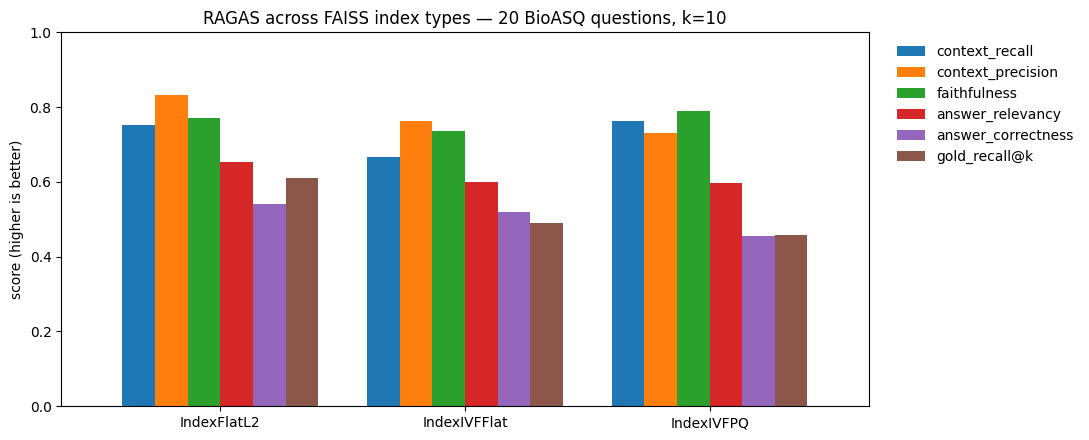

In [ ]:
import matplotlib.pyplot as plt

ax = summary.plot(kind="bar", figsize=(11, 4.5), rot=0, width=0.8)
ax.set_ylabel("score (higher is better)")
ax.set_ylim(0, 1)
ax.set_title(f"RAGAS across FAISS index types — {len(eval_set)} BioASQ questions, k={TOP_K}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# Per-question detail for one index — useful for spotting where retrieval failed.
detail = pd.DataFrame(all_scores["IndexIVFPQ"])
detail.insert(0, "question", [s["question"][:70] + "..." for s in generations["IndexIVFPQ"]])
detail.round(3).sort_values("faithfulness").head(10)

,question,context_recall,context_precision,faithfulness,answer_relevancy,answer_correctness
7,What was the purpose of the FANTOM5 project?...,1.000,0.000,0.0,0.000,0.025
12,Which method is behind HipMCL?...,0.000,0.000,0.0,0.000,0.036
19,List the main protein families found in human ...,0.222,0.750,0.0,0.000,0.040
18,which mutations of phospholamban gene have bee...,0.750,0.417,0.0,0.000,0.019
3,Are there tools for visualizing and processing...,1.000,1.000,1.0,0.220,0.721
4,Does TRIM37 gene mutation causes Mulibrey nani...,1.000,1.000,1.0,0.784,0.583
2,Glecaprevir and Pibrentasvir are used for trat...,1.000,1.000,1.0,0.876,0.959
0,What is the role of necroptosis in cancer ther...,0.750,0.808,1.0,0.858,0.540
8,Is the enzyme ERAP2 associated with the diseas...,0.500,1.000,1.0,0.692,0.515
9,Does cortical spreading depression appear in i...,1.000,1.000,1.0,0.714,0.654


### Reading the results

Expect a pattern along these lines, though your exact numbers will vary with the sample:

* **`IndexFlatL2` and `IndexIVFFlat` score nearly identically.** IVF with `nprobe=10` recovers
  almost all of the exact neighbours, so the generated answers barely differ. The speedup is
  close to free.
* **`IndexIVFPQ` gives up measurable ground** on `context_recall` and, downstream,
  `answer_correctness` — quantization loses information. In exchange the index is roughly an
  order of magnitude smaller in memory.
* **`faithfulness` is the least sensitive metric of the five.** It only asks whether the answer
  is grounded in whatever context was retrieved — a model can be perfectly faithful to bad
  passages. This is why faithfulness alone is not enough to evaluate a RAG system, and why the
  context metrics matter.

Things worth trying from here: raise `nprobe` on the IVF indexes and watch the accuracy gap to
`IndexFlatL2` close while latency rises; vary `TOP_K`; or swap `EMBED_MODEL` for a
biomedical-domain encoder such as `NeuML/pubmedbert-base-embeddings` and see how much of the
`gold_recall@k` ceiling in §3.4 that recovers.